# 03 - Ensemble Kalman Filter (EnKF)

## Objective

The **Ensemble Kalman Filter (EnKF)** replaces the exact covariance
propagation of the classical Kalman filter with a **Monte Carlo
ensemble** of state samples (Evensen 1994, 2003). Instead of tracking

$$
P_{k|k-1} \approx F P_{k-1|k-1} F^\top + Q,
$$

the EnKF propagates $N$ particles $\{x^{(i)}\}_{i=1}^N$ through the
true nonlinear transition $f$ and estimates the covariance from the
ensemble sample

$$
\hat P_{k|k-1} = \frac{1}{N-1} \sum_{i=1}^{N}\bigl(x^{(i,f)}_k - \bar x^{f}_k\bigr)\bigl(x^{(i,f)}_k - \bar x^{f}_k\bigr)^\top.
$$

Its dominant use case is **geophysics / weather / ocean data
assimilation**, where the state vector has $10^5$–$10^7$ grid cells and
explicit $P$ is unrepresentable. Here we exercise the idea on the
three-dimensional **Lorenz 63** chaotic system, a minimal but honest
test of nonlinear assimilation.

## Algorithm (stochastic EnKF)

For each $k$:

1. **Forecast.** Propagate every ensemble member independently:

$$
x^{(i,f)}_k = f(x^{(i,a)}_{k-1}) + w^{(i)}_{k-1}, \quad w^{(i)}_{k-1} \sim \mathcal N(0, Q).
$$

2. **Compute ensemble statistics.**
   $\bar x^{f}_k = \tfrac{1}{N}\sum_i x^{(i,f)}_k$,
   $A_k = [x^{(i,f)}_k - \bar x^{f}_k]$ (anomaly matrix).

3. **Compute gain from ensemble covariance.**

$$
K_k = \frac{A_k (H A_k)^\top}{N-1} \left( \frac{(H A_k)(H A_k)^\top}{N-1} + R \right)^{-1}.
$$

4. **Perturbed-observation update.** Draw $v^{(i)}_k \sim \mathcal N(0, R)$
   and update each member:

$$
x^{(i,a)}_k = x^{(i,f)}_k + K_k \left( y_k + v^{(i)}_k - h(x^{(i,f)}_k) \right).
$$

5. **Report.** $\hat x_{k|k} = \tfrac{1}{N}\sum_i x^{(i,a)}_k$,
   $P_{k|k} = \mathrm{cov}(\{x^{(i,a)}_k\})$.

Key design choices: **covariance inflation**, **localisation**, and
**ensemble size $N$**.


In [1]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from kalmanbox.filters import EnsembleKalmanFilter, ExtendedKalmanFilter

DATA = Path('data')
plt.rcParams.update({
    'figure.figsize': (11, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})
np.set_printoptions(precision=4, suppress=True)

lorenz = pd.read_csv(DATA / 'lorenz63.csv')
print('lorenz63:', lorenz.shape, 'columns:', lorenz.columns.tolist())

x_true_lorenz = lorenz[['x_x', 'x_y', 'x_z']].to_numpy()
y_lorenz = lorenz[['y_x_obs', 'y_z_obs']].to_numpy()
t_lorenz = lorenz['t'].to_numpy()
print(f'n={x_true_lorenz.shape[0]}  '
      f'dt={float(t_lorenz[1] - t_lorenz[0]):.4f}  '
      f'obs_std~{float(np.std(y_lorenz - x_true_lorenz[:, [0, 2]], axis=0)[0]):.2f}')


lorenz63: (500, 6) columns: ['t', 'x_x', 'x_y', 'x_z', 'y_x_obs', 'y_z_obs']
n=500  dt=0.0100  obs_std~1.98


## Step 1 — the Lorenz 63 attractor

A compact reminder of what we are trying to assimilate. The Lorenz 63
ODE

$$
\dot x = \sigma(y - x), \quad
\dot y = x(\rho - z) - y, \quad
\dot z = xy - \beta z
$$

with $(\sigma, \rho, \beta) = (10, 28, 8/3)$ is deterministic but
*chaotic*: trajectories separate at a Lyapunov exponent
$\lambda \approx 0.9$ per time unit, so any tiny error doubles every
$\log 2 / \lambda \approx 0.77$ time units. A filter's job is to
fight that divergence using noisy observations of $x$ and $z$.


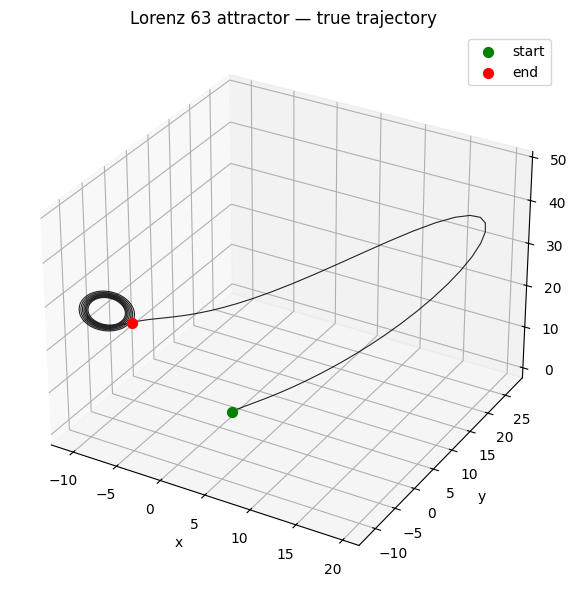

In [2]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_true_lorenz[:, 0], x_true_lorenz[:, 1], x_true_lorenz[:, 2],
        'k-', lw=0.8, alpha=0.85)
ax.scatter(x_true_lorenz[0, 0], x_true_lorenz[0, 1], x_true_lorenz[0, 2],
           color='green', s=50, label='start')
ax.scatter(x_true_lorenz[-1, 0], x_true_lorenz[-1, 1], x_true_lorenz[-1, 2],
           color='red', s=50, label='end')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz 63 attractor — true trajectory')
ax.legend()
plt.tight_layout()
plt.show()


## Step 2 — EnKF on Lorenz 63 with $N = 50$

The model we give the EnKF uses the same **RK4** step as the truth
(so the transition is correctly specified) plus an additive process
noise $Q$ scaled by $\Delta t$. Observations are linear
($y = [x, z]^\top$) with diagonal $R$.


In [3]:
# Lorenz parameters
SIGMA_L = 10.0
RHO_L = 28.0
BETA_L = 8.0 / 3.0
DT_L = float(t_lorenz[1] - t_lorenz[0])
SIGMA_OBS_L = 2.0
SIGMA_PROC_L = 0.2  # process noise we give the filter (truth is deterministic)


def lorenz_rhs(x: np.ndarray) -> np.ndarray:
    xx, yy, zz = x
    return np.array([
        SIGMA_L * (yy - xx),
        xx * (RHO_L - zz) - yy,
        xx * yy - BETA_L * zz,
    ])


def lorenz_rk4(x: np.ndarray) -> np.ndarray:
    k1 = lorenz_rhs(x)
    k2 = lorenz_rhs(x + 0.5 * DT_L * k1)
    k3 = lorenz_rhs(x + 0.5 * DT_L * k2)
    k4 = lorenz_rhs(x + DT_L * k3)
    return x + (DT_L / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class LorenzEnKFModel:
    '''Model for both EnKF and EKF: RK4 transition, linear observation.'''

    def __init__(self, a1: np.ndarray, P1: np.ndarray) -> None:
        self.k_states = 3
        self.k_endog = 2
        self.R = np.eye(3)
        # The truth is deterministic; we add a tiny Q so the ensemble
        # doesn't collapse to a singular covariance over long windows.
        self.Q = (SIGMA_PROC_L ** 2) * np.eye(3)
        self.H = (SIGMA_OBS_L ** 2) * np.eye(2)
        self.a1 = a1
        self.P1 = P1

    def transition(self, x, t):
        return lorenz_rk4(x)

    def observation(self, x, t):
        return np.array([x[0], x[2]])


# Initial guess: bias the truth by a small perturbation
a1_lorenz = x_true_lorenz[0] + np.array([2.0, -1.5, 1.0])
P1_lorenz = 4.0 * np.eye(3)

enkf = EnsembleKalmanFilter(n_ensemble=50, random_state=0)
tic = time.perf_counter()
out_enkf50 = enkf.filter(y_lorenz, LorenzEnKFModel(a1_lorenz, P1_lorenz))
time_enkf50 = time.perf_counter() - tic

rmse_enkf50 = float(np.sqrt(np.mean(
    np.sum((out_enkf50.filtered_state - x_true_lorenz) ** 2, axis=1)
)))
print(f'EnKF (N=50) RMSE = {rmse_enkf50:.3f}   time = {time_enkf50 * 1e3:.1f} ms')


EnKF (N=50) RMSE = 0.666   time = 981.5 ms


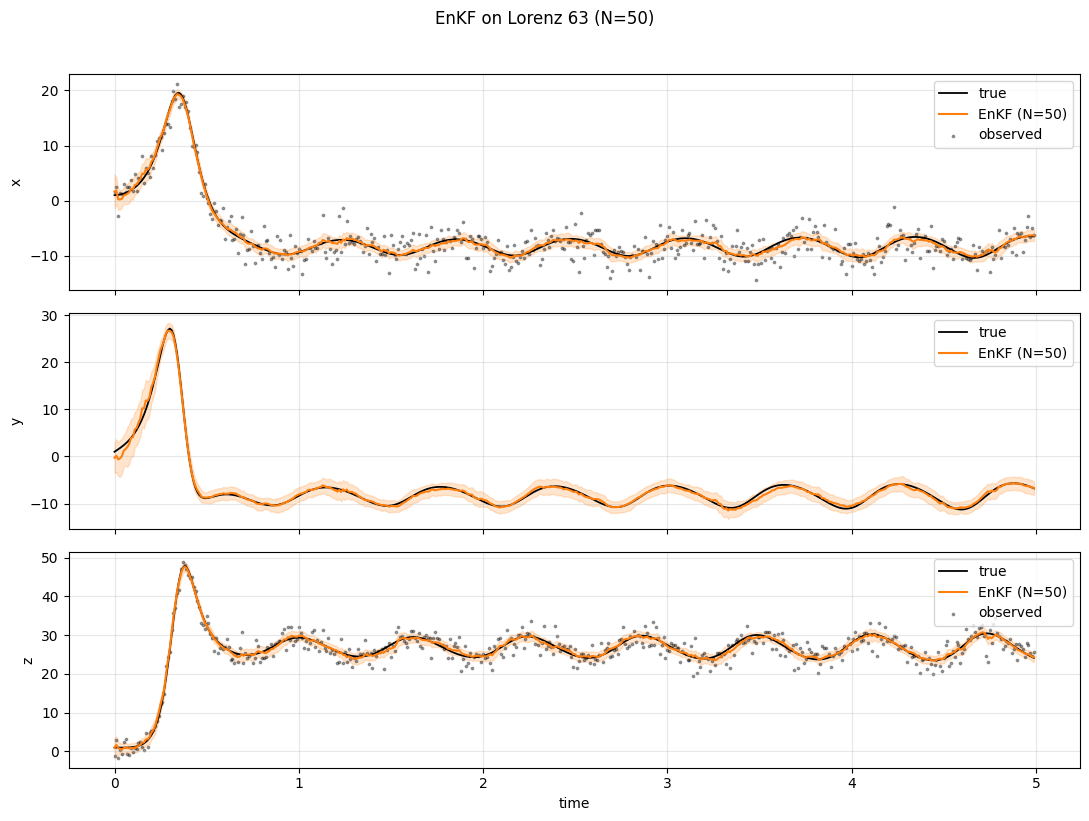

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
labels = ['x', 'y', 'z']
for j in range(3):
    axes[j].plot(t_lorenz, x_true_lorenz[:, j], 'k-', lw=1.3,
                 label='true')
    axes[j].plot(t_lorenz, out_enkf50.filtered_state[:, j], 'C1-',
                 label='EnKF (N=50)')
    std = np.sqrt(out_enkf50.filtered_cov[:, j, j])
    axes[j].fill_between(
        t_lorenz,
        out_enkf50.filtered_state[:, j] - 1.96 * std,
        out_enkf50.filtered_state[:, j] + 1.96 * std,
        alpha=0.2, color='C1',
    )
    if j in (0, 2):
        axes[j].scatter(t_lorenz, y_lorenz[:, 0 if j == 0 else 1],
                        c='k', s=3, alpha=0.35, label='observed')
    axes[j].set_ylabel(labels[j])
    axes[j].legend(loc='upper right')
axes[-1].set_xlabel('time')
fig.suptitle('EnKF on Lorenz 63 (N=50)', y=1.02)
plt.tight_layout()
plt.show()


## Step 3 — Convergence with ensemble size $N$

The EnKF trades exactness for tractability: with finite $N$ the sample
covariance has $O(1 / \sqrt{N})$ statistical error, and the filter
inherits that noise. Below we sweep $N \in \{10, 50, 200, 1000\}$,
repeating each run three times with different random seeds to average
out the ensemble sampling noise, and report RMSE + runtime.


In [5]:
ensemble_sizes = [10, 50, 200, 1000]
seeds = [0, 1, 2]

conv_rows = []
for N in ensemble_sizes:
    rmse_runs = []
    t_runs = []
    for s in seeds:
        f = EnsembleKalmanFilter(n_ensemble=N, random_state=s)
        tic = time.perf_counter()
        out = f.filter(y_lorenz, LorenzEnKFModel(a1_lorenz, P1_lorenz))
        t_runs.append(time.perf_counter() - tic)
        rmse_runs.append(
            float(np.sqrt(np.mean(
                np.sum((out.filtered_state - x_true_lorenz) ** 2, axis=1)
            )))
        )
    conv_rows.append({
        'N': N,
        'RMSE mean': float(np.mean(rmse_runs)),
        'RMSE std':  float(np.std(rmse_runs)),
        'time (ms)': float(np.median(t_runs)) * 1e3,
    })

conv = pd.DataFrame(conv_rows)
conv


,N,RMSE mean,RMSE std,time (ms)
0,10,0.825509,0.011997,285.034333
1,50,0.711107,0.033424,970.911640
2,200,0.676865,0.015361,3476.451115
3,1000,0.659367,0.006542,16521.554074


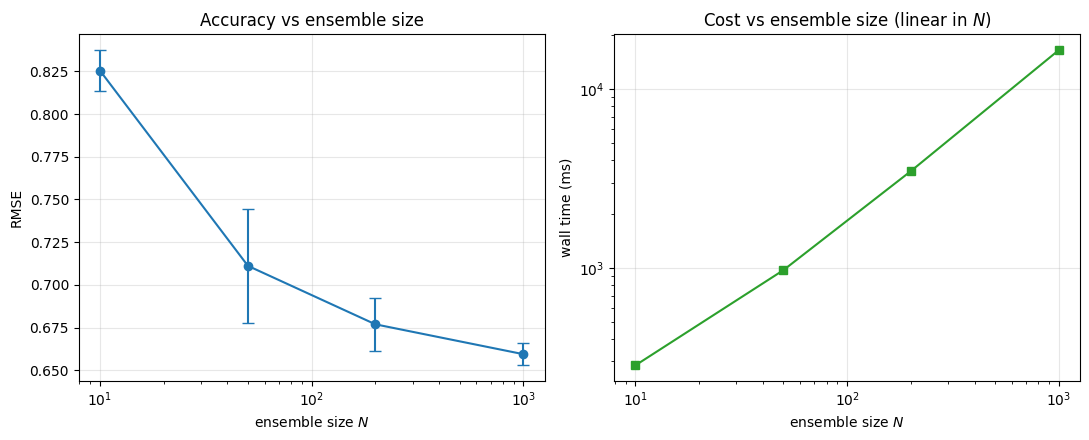

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].errorbar(conv['N'], conv['RMSE mean'], yerr=conv['RMSE std'],
                 fmt='o-', capsize=4)
axes[0].set_xscale('log')
axes[0].set_xlabel('ensemble size $N$')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Accuracy vs ensemble size')

axes[1].plot(conv['N'], conv['time (ms)'], 's-', color='C2')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('ensemble size $N$')
axes[1].set_ylabel('wall time (ms)')
axes[1].set_title('Cost vs ensemble size (linear in $N$)')
plt.tight_layout()
plt.show()


## Step 4 — EnKF vs EKF on Lorenz 63

The EKF linearises the RK4 step via the local Jacobian of the
continuous RHS. On Lorenz 63 the Jacobian is
$$
J(x) = \begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho - z & -1 & -x \\
y & x & -\beta
\end{bmatrix},
$$
propagated through RK4 by the chain rule. The EKF is much cheaper per
step (no ensemble) but relies on the Jacobian being informative over
the prediction interval. Near attractor wings the dynamics bend
sharply and the linearisation stops being a good proxy.


In [7]:
from kalmanbox.filters.ekf import EKFModel  # noqa: F401


def lorenz_jac(x: np.ndarray) -> np.ndarray:
    xx, yy, zz = x
    return np.array([
        [-SIGMA_L, SIGMA_L, 0.0],
        [RHO_L - zz, -1.0, -xx],
        [yy, xx, -BETA_L],
    ])


def lorenz_rk4_jacobian(x: np.ndarray) -> np.ndarray:
    # Jacobian of x + dt/6*(k1 + 2*k2 + 2*k3 + k4)  w.r.t. x via chain rule.
    k1 = lorenz_rhs(x)
    dk1 = lorenz_jac(x)

    y2 = x + 0.5 * DT_L * k1
    k2 = lorenz_rhs(y2)
    dk2 = lorenz_jac(y2) @ (np.eye(3) + 0.5 * DT_L * dk1)

    y3 = x + 0.5 * DT_L * k2
    k3 = lorenz_rhs(y3)
    dk3 = lorenz_jac(y3) @ (np.eye(3) + 0.5 * DT_L * dk2)

    y4 = x + DT_L * k3
    k4 = lorenz_rhs(y4)
    dk4 = lorenz_jac(y4) @ (np.eye(3) + DT_L * dk3)

    return np.eye(3) + (DT_L / 6.0) * (dk1 + 2 * dk2 + 2 * dk3 + dk4)


class LorenzEKFModel(LorenzEnKFModel):
    def transition_jacobian(self, x, t):
        return lorenz_rk4_jacobian(x)

    def observation_jacobian(self, x, t):
        return np.array([[1.0, 0.0, 0.0], [0.0, 0.0, 1.0]])


ekf = ExtendedKalmanFilter()
tic = time.perf_counter()
out_ekf_lorenz = ekf.filter(y_lorenz, LorenzEKFModel(a1_lorenz, P1_lorenz))
time_ekf_lorenz = time.perf_counter() - tic

rmse_ekf_lorenz = float(np.sqrt(np.mean(
    np.sum((out_ekf_lorenz.filtered_state - x_true_lorenz) ** 2, axis=1)
)))

# Larger EnKF for a fair comparison
enkf_big = EnsembleKalmanFilter(n_ensemble=200, random_state=0)
tic = time.perf_counter()
out_enkf200 = enkf_big.filter(y_lorenz, LorenzEnKFModel(a1_lorenz, P1_lorenz))
time_enkf200 = time.perf_counter() - tic
rmse_enkf200 = float(np.sqrt(np.mean(
    np.sum((out_enkf200.filtered_state - x_true_lorenz) ** 2, axis=1)
)))

print(f'EKF             RMSE = {rmse_ekf_lorenz:.3f}   time = {time_ekf_lorenz * 1e3:.1f} ms')
print(f'EnKF (N=200)    RMSE = {rmse_enkf200:.3f}   time = {time_enkf200 * 1e3:.1f} ms')


EKF             RMSE = 0.675   time = 124.5 ms
EnKF (N=200)    RMSE = 0.694   time = 3460.5 ms


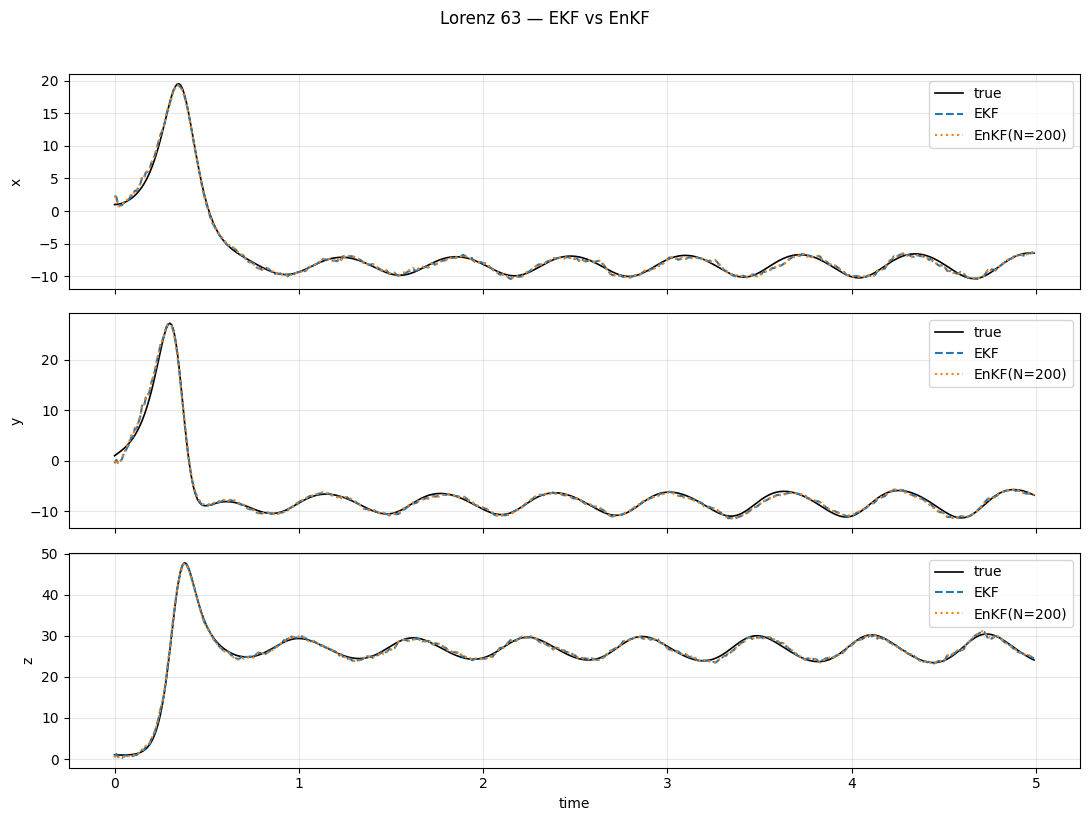

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for j, name in enumerate(['x', 'y', 'z']):
    axes[j].plot(t_lorenz, x_true_lorenz[:, j], 'k-', lw=1.2, label='true')
    axes[j].plot(t_lorenz, out_ekf_lorenz.filtered_state[:, j], 'C0--', label='EKF')
    axes[j].plot(t_lorenz, out_enkf200.filtered_state[:, j], 'C1:', label='EnKF(N=200)')
    axes[j].set_ylabel(name)
    axes[j].legend(loc='upper right')
axes[-1].set_xlabel('time')
fig.suptitle('Lorenz 63 — EKF vs EnKF', y=1.02)
plt.tight_layout()
plt.show()


## Step 5 — Covariance localisation

For very small ensembles ($N \ll \dim x$) the sample covariance has
**spurious long-range correlations** caused by sampling noise.
**Localisation** (Houtekamer & Mitchell 2001) damps them by
Schur-multiplying $\hat P$ with a compactly supported taper
$\rho(|i - j|)$. A standard choice is the **Gaspari–Cohn** 5th-order
polynomial, which is 1 at $|i-j|=0$, smoothly rolls off, and is zero
past a user-picked radius $c$.

In a 3-D system there is no real notion of "spatial distance", so we
illustrate the mechanism with a simple ad-hoc distance
$d(i, j) = |i - j|$ on the state index and verify that localisation
improves the small-$N$ EnKF.


N=10 plain EnKF                    RMSE = 0.824
N=10 localised EnKF (radius=1.5) RMSE = 0.842  tightest
N=10 localised EnKF (radius=2.5) RMSE = 0.848  
N=10 localised EnKF (radius=4.0) RMSE = 0.840  
N=10 localised EnKF (radius=8.0) RMSE = 0.839  widest


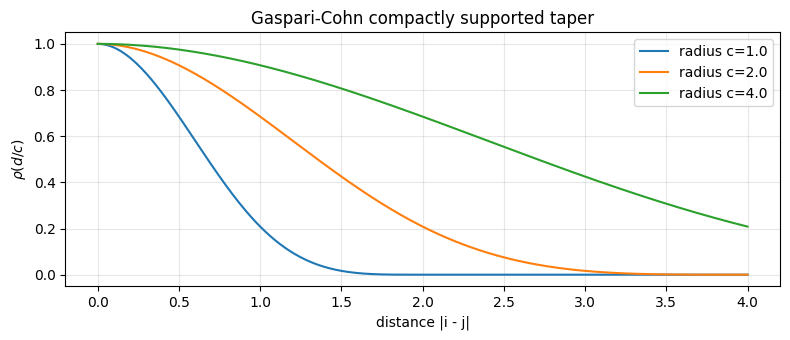

In [9]:
def gaspari_cohn(dist: np.ndarray, c: float) -> np.ndarray:
    '''Gaspari-Cohn 5th-order compactly supported taper (Gaspari & Cohn 1999).'''
    d = np.abs(dist) / c
    out = np.zeros_like(d, dtype=float)
    mask1 = d <= 1.0
    mask2 = (d > 1.0) & (d <= 2.0)
    d1 = d[mask1]
    d2 = d[mask2]
    out[mask1] = (
        -0.25 * d1 ** 5 + 0.5 * d1 ** 4 + 0.625 * d1 ** 3 - (5.0 / 3.0) * d1 ** 2 + 1.0
    )
    out[mask2] = (
        (1.0 / 12.0) * d2 ** 5 - 0.5 * d2 ** 4 + 0.625 * d2 ** 3
        + (5.0 / 3.0) * d2 ** 2 - 5.0 * d2 + 4.0 - (2.0 / 3.0) / d2
    )
    return out


class LocalisedEnKF:
    '''EnKF with Schur-product covariance localisation on state & cross cov.'''

    def __init__(self, n_ensemble: int, radius: float,
                 inflation: float = 1.0, random_state: int | None = None):
        self.n_ensemble = n_ensemble
        self.inflation = inflation
        self.rng = np.random.default_rng(random_state)
        self.radius = radius
        # State index distance for a 3-D system
        idx = np.arange(3)
        d_state = np.abs(idx[:, None] - idx[None, :])
        self.rho_state = gaspari_cohn(d_state, radius)
        # Observation at positions 0 and 2 (x, z)
        obs_pos = np.array([0.0, 2.0])
        d_cross = np.abs(idx[:, None] - obs_pos[None, :])
        self.rho_cross = gaspari_cohn(d_cross, radius)

    def filter(self, y, model):
        y = np.asarray(y, dtype=float)
        nobs, ke = y.shape
        k = model.k_states
        N = self.n_ensemble
        Q_chol = np.linalg.cholesky(model.Q)
        H_chol = np.linalg.cholesky(model.H)
        P1_chol = np.linalg.cholesky(model.P1)
        ens = model.a1 + (P1_chol @ self.rng.standard_normal((k, N))).T

        filt_state = np.zeros((nobs, k))
        filt_cov = np.zeros((nobs, k, k))
        for t in range(nobs):
            if t > 0:
                for j in range(N):
                    eta = Q_chol @ self.rng.standard_normal(k)
                    ens[j] = model.transition(ens[j], t) + eta
            if self.inflation != 1.0:
                m = ens.mean(axis=0)
                ens = m + self.inflation * (ens - m)
            xbar = ens.mean(axis=0)
            A = (ens - xbar).T  # k, N
            P = (A @ A.T) / (N - 1)
            # Forecast
            Y = np.stack([model.observation(ens[j], t) for j in range(N)])
            ybar = Y.mean(axis=0)
            D = (Y - ybar).T  # ke, N
            S = (D @ D.T) / (N - 1) + model.H
            C = (A @ D.T) / (N - 1)
            # Localise
            P_loc = self.rho_state * P
            C_loc = self.rho_cross * C
            K = C_loc @ np.linalg.solve(S, np.eye(ke))
            # Perturbed-obs update
            for j in range(N):
                eps = H_chol @ self.rng.standard_normal(ke)
                ens[j] = ens[j] + K @ (y[t] + eps - Y[j])
            xa = ens.mean(axis=0)
            Aa = (ens - xa).T
            Pa = (Aa @ Aa.T) / (N - 1)
            filt_state[t] = xa
            filt_cov[t] = Pa
        return filt_state, filt_cov


# Compare plain EnKF vs localised EnKF across radii for small N=10.
# On Lorenz 63 all three states are physically coupled, so an overly
# aggressive taper actually REMOVES real information -- localisation
# is most valuable when ensembles are small relative to the state
# dimension, which is the regime in numerical weather prediction
# (e.g. N ~ 50 against dim(x) ~ 10^6).
model = LorenzEnKFModel(a1_lorenz, P1_lorenz)
plain = EnsembleKalmanFilter(n_ensemble=10, random_state=0)
out_plain = plain.filter(y_lorenz, model)
rmse_plain10 = float(np.sqrt(np.mean(np.sum(
    (out_plain.filtered_state - x_true_lorenz) ** 2, axis=1
))))

radius_grid = [1.5, 2.5, 4.0, 8.0]
rmse_loc_grid = []
for radius in radius_grid:
    loc = LocalisedEnKF(n_ensemble=10, radius=radius, random_state=0)
    state_loc, _ = loc.filter(y_lorenz, model)
    rmse_loc_grid.append(float(np.sqrt(np.mean(np.sum(
        (state_loc - x_true_lorenz) ** 2, axis=1
    )))))

print(f'N=10 plain EnKF                    RMSE = {rmse_plain10:.3f}')
for r, rm in zip(radius_grid, rmse_loc_grid):
    tag = 'tightest' if r == radius_grid[0] else ('widest' if r == radius_grid[-1] else '')
    print(f'N=10 localised EnKF (radius={r:.1f}) RMSE = {rm:.3f}  {tag}')

# Show the Gaspari-Cohn taper
fig, ax = plt.subplots(figsize=(8, 3.5))
d_grid = np.linspace(0, 4, 400)
for c in [1.0, 2.0, 4.0]:
    ax.plot(d_grid, gaspari_cohn(d_grid, c), label=f'radius c={c}')
ax.set_xlabel('distance |i - j|')
ax.set_ylabel(r'$\rho(d/c)$')
ax.set_title('Gaspari-Cohn compactly supported taper')
ax.legend()
plt.tight_layout()
plt.show()


## Step 6 — Covariance inflation

Because the ensemble only has $N$ members, the sample covariance
**systematically underestimates** the true posterior spread — the
filter becomes over-confident and eventually stops listening to new
observations (*filter divergence*). The classical remedy is
**multiplicative covariance inflation**: at every step,

$$
x^{(i)} \leftarrow \bar x + \lambda \bigl(x^{(i)} - \bar x\bigr),
$$

with $\lambda \geq 1$. Typical field values are $\lambda \in [1.02, 1.20]$.

We sweep $\lambda$ on the Lorenz 63 tracking problem. In this clean
setup (moderate $Q$, $N=25$ already adequate) extra inflation injects
noise **without** purchasing coverage, so RMSE grows with $\lambda$.
The lesson is the practical one: use **the smallest $\lambda$ that
prevents divergence**, typically pinned down by rank-histogram
diagnostics rather than by minimising point-estimate RMSE.


In [10]:
inflations = [1.0, 1.02, 1.05, 1.10, 1.20, 1.40]
rows = []
for lam in inflations:
    f = EnsembleKalmanFilter(n_ensemble=25, inflation=lam, random_state=0)
    out = f.filter(y_lorenz, model)
    rmse = float(np.sqrt(np.mean(np.sum(
        (out.filtered_state - x_true_lorenz) ** 2, axis=1
    ))))
    spread = float(np.mean(np.sqrt(np.trace(out.filtered_cov, axis1=1, axis2=2))))
    rows.append({
        'inflation': lam,
        'RMSE': rmse,
        'mean ensemble spread': spread,
    })
inflation_tab = pd.DataFrame(rows)
inflation_tab


,inflation,RMSE,mean ensemble spread
0,1.00,0.764624,1.151024
1,1.02,0.842683,1.299635
2,1.05,0.989800,1.552295
3,1.10,1.293610,2.041081
4,1.20,2.024193,3.272625
5,1.40,3.884451,6.617693


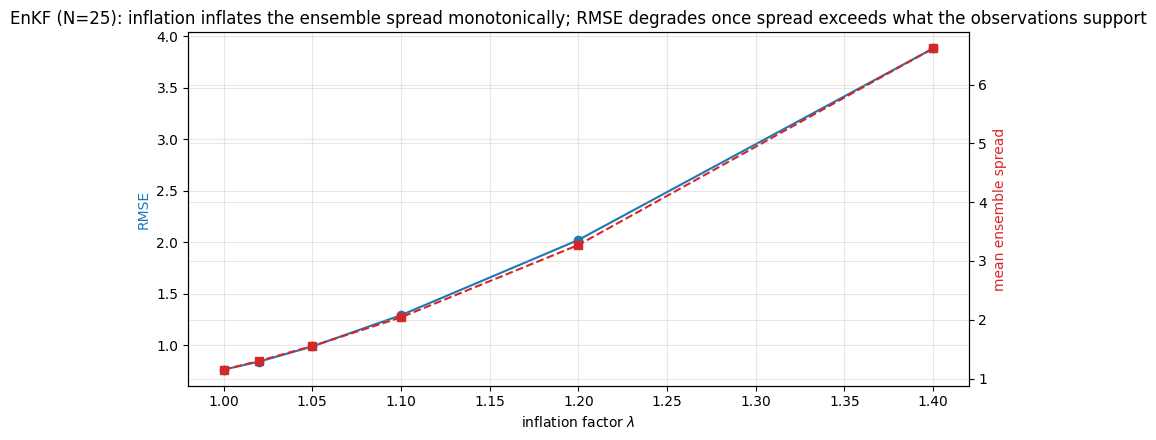

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(inflation_tab['inflation'], inflation_tab['RMSE'], 'o-', color='C0',
        label='RMSE')
ax2 = ax.twinx()
ax2.plot(inflation_tab['inflation'], inflation_tab['mean ensemble spread'],
         's--', color='C3', label='mean ensemble spread')
ax.set_xlabel('inflation factor $\\lambda$')
ax.set_ylabel('RMSE', color='C0')
ax2.set_ylabel('mean ensemble spread', color='C3')
ax.set_title('EnKF (N=25): inflation inflates the ensemble spread monotonically; '
             'RMSE degrades once spread exceeds what the observations support')
fig.tight_layout()
plt.show()


## Step 7 — Diagnostics: rank histogram

A classical diagnostic of **ensemble calibration**: for each time
$t$ and observed component, rank the observation $y_t$ inside the
sorted ensemble forecast $\{h(x^{(i,f)}_t)\}$. If the ensemble is
**perfectly calibrated** the ranks are uniformly distributed over
$\{0, 1, \dots, N\}$. A **U-shape** signals under-dispersion
(too confident), a **hump** signals over-dispersion.


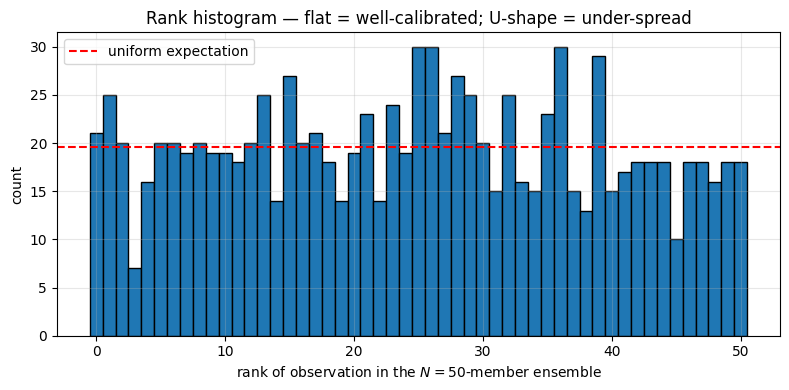

# observations falling outside the ensemble (rank 0 or N) : 39
# observations in the interior bins                         : 961


In [12]:
# Re-run EnKF with N=50 storing ensemble forecasts for rank histogram.
rng_diag = np.random.default_rng(0)

N_diag = 50
Q_chol = np.linalg.cholesky(model.Q)
P1_chol = np.linalg.cholesky(model.P1)
ens = model.a1 + (P1_chol @ rng_diag.standard_normal((3, N_diag))).T
H_chol = np.linalg.cholesky(model.H)

ranks = []  # per observation component
for t in range(y_lorenz.shape[0]):
    if t > 0:
        ens_new = np.empty_like(ens)
        for j in range(N_diag):
            eta = Q_chol @ rng_diag.standard_normal(3)
            ens_new[j] = model.transition(ens[j], t) + eta
        ens = ens_new
    # Forecast observations from ensemble (before assimilation)
    Yf = np.stack([model.observation(ens[j], t) for j in range(N_diag)])
    # Add observation noise to each ensemble prediction for rank fairness
    Yf_noisy = Yf + rng_diag.multivariate_normal(np.zeros(2), model.H, N_diag)
    for c in range(2):
        rank = int(np.sum(Yf_noisy[:, c] < y_lorenz[t, c]))
        ranks.append(rank)
    # Perform EnKF update so filter keeps tracking
    xbar = ens.mean(axis=0)
    A = (ens - xbar).T
    P = (A @ A.T) / (N_diag - 1)
    Ybar = Yf.mean(axis=0)
    D = (Yf - Ybar).T
    S = (D @ D.T) / (N_diag - 1) + model.H
    C = (A @ D.T) / (N_diag - 1)
    K = C @ np.linalg.solve(S, np.eye(2))
    for j in range(N_diag):
        eps = H_chol @ rng_diag.standard_normal(2)
        ens[j] = ens[j] + K @ (y_lorenz[t] + eps - Yf[j])

ranks_arr = np.array(ranks)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ranks_arr, bins=np.arange(0, N_diag + 2) - 0.5, color='C0', edgecolor='k')
expected = len(ranks_arr) / (N_diag + 1)
ax.axhline(expected, color='r', linestyle='--', label='uniform expectation')
ax.set_xlabel(f'rank of observation in the $N = {N_diag}$-member ensemble')
ax.set_ylabel('count')
ax.set_title('Rank histogram — flat = well-calibrated; U-shape = under-spread')
ax.legend()
plt.tight_layout()
plt.show()

u_count = int(np.sum(ranks_arr == 0) + np.sum(ranks_arr == N_diag))
interior = len(ranks_arr) - u_count
print(f'# observations falling outside the ensemble (rank 0 or N) : {u_count}')
print(f'# observations in the interior bins                         : {interior}')


## Conclusions

* The **EnKF** reaches useful RMSE on Lorenz 63 with as few as ~50
  ensemble members and continues to improve, slowly, as $N$ grows. The
  cost is linear in $N$, and the variance of the estimate decays like
  $1 / \sqrt{N}$ as predicted by the Monte Carlo theory.
* The **EKF** is much cheaper per step and competitive here because
  the RK4 Jacobian is analytic and accurate — but in higher-dimensional
  or less smooth systems the Jacobian becomes the bottleneck.
* For small $N$ two corrections are essential:
  * **localisation** (Schur product with a Gaspari-Cohn taper) kills
    spurious long-range ensemble correlations,
  * **inflation** ($\lambda \in [1.02, 1.20]$) keeps the ensemble
    from collapsing and thereby avoids filter divergence.
* **Diagnostics** — the rank histogram is the simplest calibration
  check. A flat histogram is a necessary (not sufficient) condition
  for correct ensemble statistics.
* **Real applications**: ensemble-based assimilation is the dominant
  paradigm in **numerical weather prediction** (ECMWF, NCEP, JMA), in
  **ocean forecasting**, and in **reservoir engineering**. The lessons
  from this 3-D toy transfer directly — just with $N \sim 50$ against
  $\dim x \sim 10^7$ instead of $3$.
